In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Handwritten digits

In [2]:
digits = datasets.load_digits()
print(digits.images.shape) # I have 1797 images of shape 8x8 pixels (use this only for printing images)
print(digits.target.shape) # I have 1797 labels
print(digits.data.shape) # I have 1797 images of 64 pixels (use this to do machine learning)
print(digits.keys())

(1797, 8, 8)
(1797,)
(1797, 64)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 5)


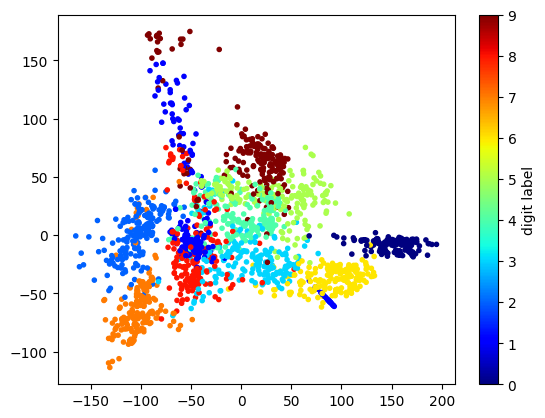

In [19]:
# Dimensionality reduction from 64 to 2 with an unsupervised method
X = digits.data
y = digits.target
embedding = Isomap(n_components=5)
X_transformed = embedding.fit_transform(X)
print(X_transformed.shape)
plt.scatter(X_transformed[:,0], X_transformed[:,4], c=y, cmap="jet", marker=".")
plt.colorbar(label="digit label", ticks=range(10))
plt.show()

In [11]:
# Split the dataset taking 80% of the images as tranining dataset and leaving the other 20% as a validation set
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X_transformed, y, range(len(X_transformed)), test_size=0.2, random_state=42)

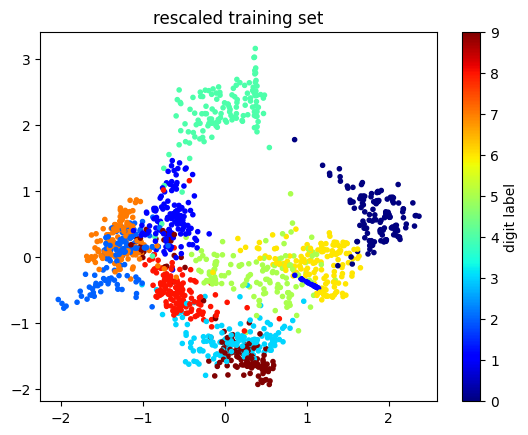

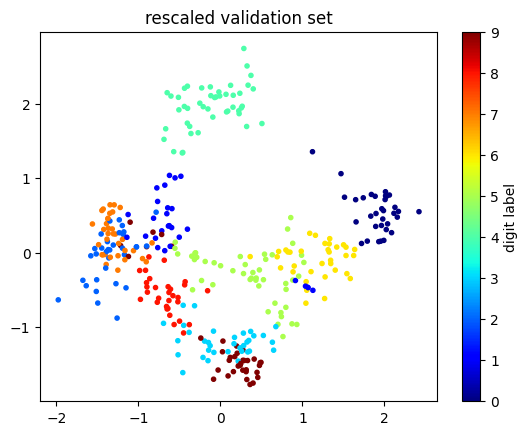

Classifier converged [27]


In [12]:
# Rescaling to use the solver "sag" (Stochastic Average Gradient)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

plt.scatter(X_train_scaled[:,0], X_train_scaled[:,1], c=y_train, cmap="jet", marker=".")
plt.colorbar(label="digit label", ticks=range(10))
plt.title("rescaled training set")
plt.show()

plt.scatter(X_test_scaled[:,0], X_test_scaled[:,1], c=y_test, cmap="jet", marker=".")
plt.colorbar(label="digit label", ticks=range(10))
plt.title("rescaled validation set")
plt.show()

# Training the classifier
classifier = LogisticRegression(solver="sag", max_iter=1000)
classifier.fit(X_train_scaled, y_train)
print("Classifier converged", classifier.n_iter_)

In [13]:
# In this context, accuracy is simply the fraction of the digits that were correctly identified.
# Compute the accuracy on both the training and the validation set
y_test_pred = classifier.predict(X_test_scaled)
y_train_pred = classifier.predict(X_train_scaled)
print(f"Accuracy on validation set: {accuracy_score(y_test, y_test_pred): .4f}")
print(f"Accuracy on training set: {accuracy_score(y_train, y_train_pred): .4f}")

Accuracy on validation set:  0.9639
Accuracy on training set:  0.9722


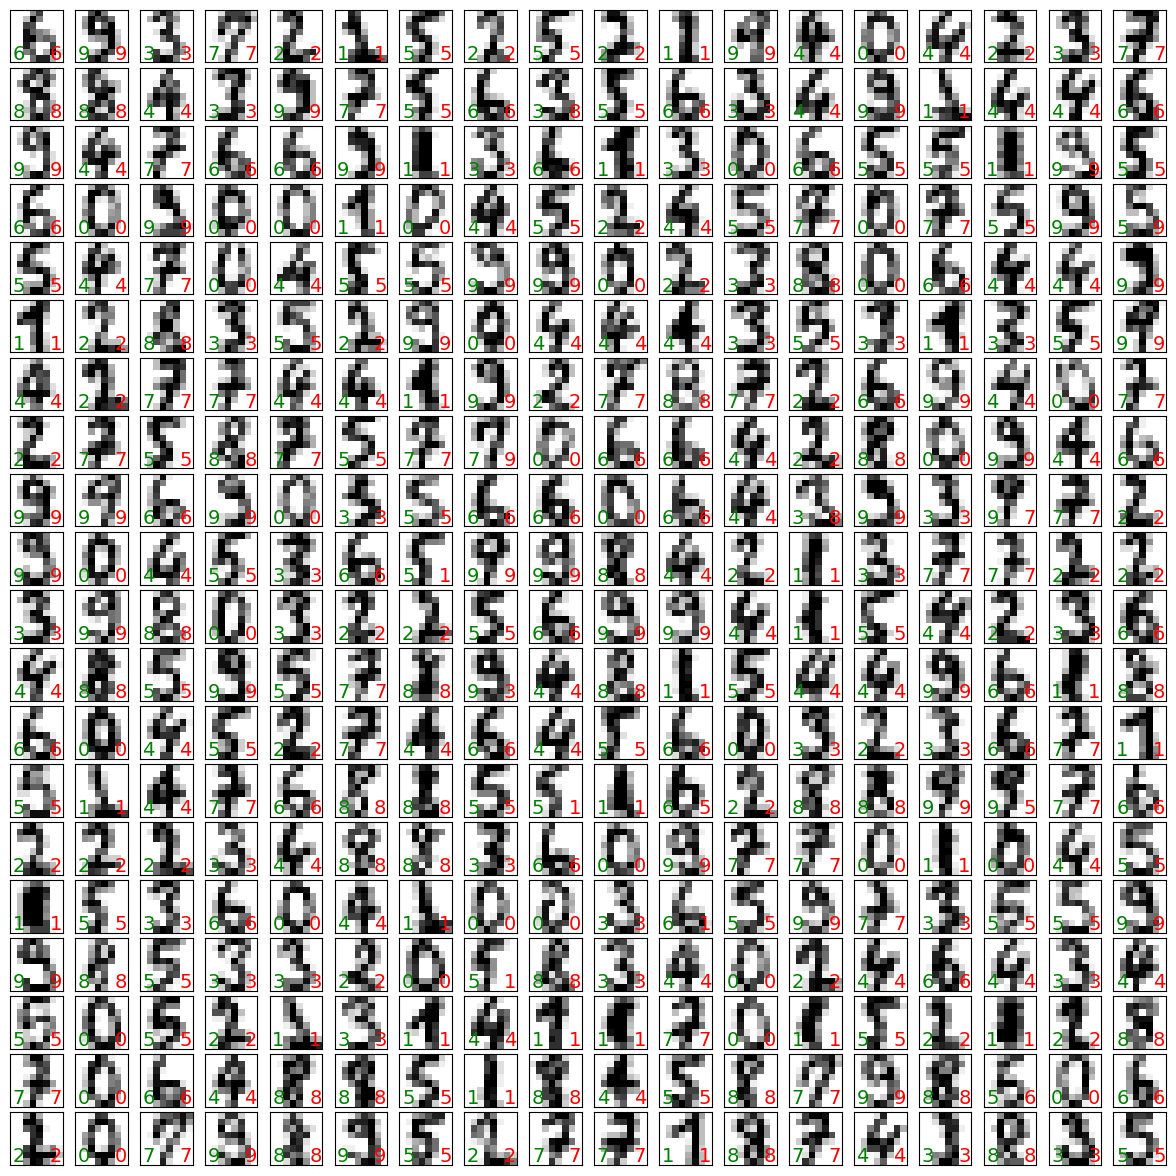

In [14]:
fig, axes = plt.subplots(20, 18, figsize=(15, 15))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[test_idx[i]]), cmap='binary')
    ax.text(0.05, 0.05, str(y_test[i]), transform=ax.transAxes, color='green', fontsize=14) # True label
    ax.text(0.75, 0.05, str(y_test_pred[i]), transform=ax.transAxes, color='red', fontsize=14) # Predicted label
    ax.set_xticks([])
    ax.set_yticks([])

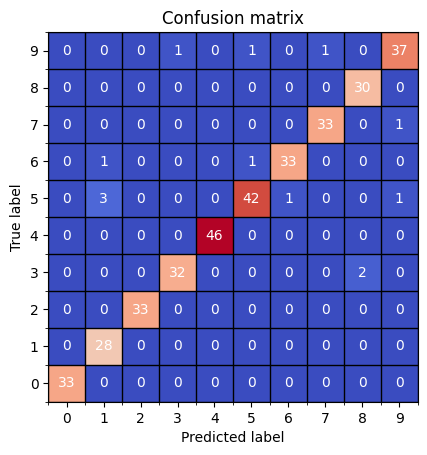

In [15]:
# The accuracy is a single number doesn't tell us where we've gone wrong.
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.imshow(cm, origin="lower", cmap="coolwarm")
plt.title("Confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="white")
plt.xticks(np.arange(cm.shape[1]), labels=np.arange(cm.shape[1]))
plt.yticks(np.arange(cm.shape[0]), labels=np.arange(cm.shape[0]))
plt.gca().set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
plt.gca().set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
plt.grid(which='minor', color='black', linestyle='-', linewidth=1)
plt.gca().set_aspect('equal')
plt.show()

In [20]:
# What are the digits that are more challenging to identify, does it make sense?
# This depends on the number of reducted components you decide to use inh Isomap, n=2 is not sufficient to distinguish 3 and 9

# Recap: Scikit-learn's estimator interface

Scikit-learn strives to have a uniform interface (API) across all methods, and we'll see examples of these below. Given a scikit-learn ***estimator*** object named `model`, the following methods are available:

- Available in **all Estimators**
     - `model.fit()`: fit training data. For supervised learning applications, this accepts two arguments: the data `X` and the labels `y` [e.g., `model.fit(X, y)`].  For unsupervised learning applications, this accepts only a single argument, the data `X` [e.g., `model.fit(X)`].
  
  
- Available in **supervised estimators**
    - `model.predict()`: given a trained model, predict the label of a new set of data. This method accepts one argument, the new data `X_new` [e.g., `model.predict(X_new)`], and returns the learned label for each object in the array.
    - `model.predict_proba()`: For classification problems, some estimators also provide this method, which returns the probability that a new observation has each categorical label. In this case, the label with the highest probability is returned by `model.predict()`.
    - `model.score()`: For classification or regression problems, most (all?) estimators implement a score method.  Scores are between 0 and 1, with a larger score indicating a better fit.
    
    
- Available in **unsupervised estimators**
    - `model.transform()`: given an unsupervised model, transform new data into the new basis. This also accepts one argument `X_new`, and returns the new representation of the data based on the unsupervised model.
    - `model.fit_transform()`: some estimators implement this method, which more efficiently performs a fit and a transform on the same input data.